Шаг 1 - импорт библиотек

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Алгоритмы обнаружения аномалий
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

print("Библиотеки импортированы!")

Библиотеки импортированы!


Импортировали все необходимые библиотеки: pandas, numpy, matplotlib, seaborn для работы с данными и визуализации, а также LocalOutlierFactor и IsolationForest из sklearn для обнаружения аномалий.

Шаг 2 — загрузка и изучение файла diy.txt.

In [2]:
# Загружаем файл diy.txt
df_diy = pd.read_csv('diy.txt', sep=',')

# Смотрим размер
print("Размер датасета:", df_diy.shape)

# Смотрим названия колонок
print("\nНазвания колонок:")
print(df_diy.columns.tolist())

# Смотрим первые строки
print("\nПервые 5 строк:")
df_diy.head()

Размер датасета: (42746, 5)

Названия колонок:
['ClientID', 'Recency', 'Frequency', 'Monetary_Q', 'Monetary_A']

Первые 5 строк:


,ClientID,Recency,Frequency,Monetary_Q,Monetary_A
0,client13166,682,2,23,2705
1,client1239,35,43,219,42161
2,client30041,190,25,133,16057
3,client36276,289,4,12,4614
4,client14136,217,6,36,35870


Загрузили датасет diy.txt — 42 746 клиентов и 5 колонок: ClientID (ID клиента), Recency (давность в днях), Frequency (частота визитов), Monetary_Q (количество покупок), Monetary_A (сумма покупок).

Шаг 3 — фильтрация данных. По заданию нужно использовать только два признака — Frequency и Monetary_A, и оставить только клиентов у которых Frequency > 1 (то есть приходили больше одного раза).

In [3]:
# Фильтруем - только клиенты с частотой больше 1
df_diy_filtered = df_diy[df_diy['Frequency'] > 1].copy()

print("Размер до фильтрации:", df_diy.shape)
print("Размер после фильтрации:", df_diy_filtered.shape)

# Оставляем только нужные признаки
X_diy = df_diy_filtered[['Frequency', 'Monetary_A']]

print("\nПервые 5 строк итоговых признаков:")
X_diy.head()

Размер до фильтрации: (42746, 5)
Размер после фильтрации: (29887, 5)

Первые 5 строк итоговых признаков:


,Frequency,Monetary_A
0,2,2705
1,43,42161
2,25,16057
3,4,4614
4,6,35870


Отфильтровали клиентов с частотой визитов больше 1. Из 42 746 клиентов осталось 29 887. Оставили только два признака: Frequency (частота) и Monetary_A (сумма покупок).

Шаг 4 — применяем алгоритм LOF. Алгоритм вернёт для каждого клиента метку: -1 означает аномалия, 1 означает норма.

In [4]:
# Создаём и обучаем модель LOF
lof = LocalOutlierFactor(n_neighbors=20, novelty=False)

# Получаем метки: -1 = аномалия, 1 = норма
labels_diy = lof.fit_predict(X_diy)

# Добавляем метки в датафрейм
df_diy_filtered = df_diy_filtered.copy()
df_diy_filtered['LOF_label'] = labels_diy

# Считаем сколько аномалий нашли
n_outliers = (labels_diy == -1).sum()
n_normal = (labels_diy == 1).sum()

print(f"Нормальных клиентов: {n_normal}")
print(f"Аномальных клиентов: {n_outliers}")
print(f"Доля аномалий: {n_outliers/len(labels_diy)*100:.2f}%")

Нормальных клиентов: 29746
Аномальных клиентов: 141
Доля аномалий: 0.47%


Алгоритм LOF обнаружил 141 аномального клиента из 29 887 — это около 0.47% от всей выборки. Остальные 29 746 клиентов признаны нормальными.

Шаг 5 — визуализируем результат. Посмотрим на графике кто аномалия а кто нет.

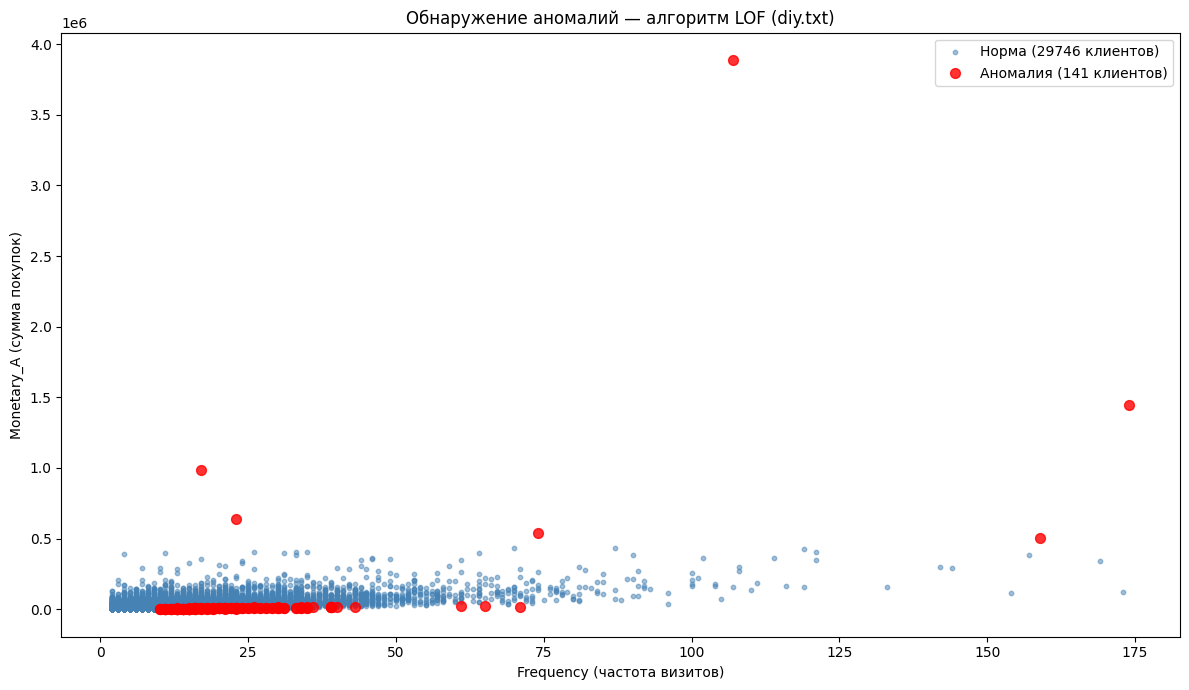


Топ-10 аномальных клиентов:
          ClientID  Frequency  Monetary_A
18474  client29182        107     3887309
2611   client15654        174     1443255
26214   client8778         17      986618
32747   client1704         23      636101
531    client33032         74      537397
8763   client37582        159      502515
358    client34917         65       25491
1699   client13712         61       20021
849    client35854         71       17289
26806  client33785         40       16873


In [5]:
# Разделяем нормальных и аномальных клиентов
normal = df_diy_filtered[df_diy_filtered['LOF_label'] == 1]
outliers = df_diy_filtered[df_diy_filtered['LOF_label'] == -1]

# Строим график
plt.figure(figsize=(12, 7))

# Нормальные клиенты - синие точки
plt.scatter(
    normal['Frequency'], 
    normal['Monetary_A'],
    c='steelblue', 
    alpha=0.5, 
    s=10,
    label=f'Норма ({len(normal)} клиентов)'
)

# Аномальные клиенты - красные точки
plt.scatter(
    outliers['Frequency'], 
    outliers['Monetary_A'],
    c='red', 
    alpha=0.8, 
    s=50,
    label=f'Аномалия ({len(outliers)} клиентов)'
)

plt.xlabel('Frequency (частота визитов)')
plt.ylabel('Monetary_A (сумма покупок)')
plt.title('Обнаружение аномалий — алгоритм LOF (diy.txt)')
plt.legend()
plt.tight_layout()
plt.show()

# Смотрим на самих аномальных клиентов
print("\nТоп-10 аномальных клиентов:")
print(outliers[['ClientID', 'Frequency', 'Monetary_A']].sort_values('Monetary_A', ascending=False).head(10))

Визуализировали результаты LOF. На графике чётко видно — красные точки (аномалии) это клиенты с очень высокой суммой покупок (до 3.9 млн) или очень высокой частотой визитов (до 174). Лидер аномалий — client29182 с частотой 107 визитов и суммой почти 3.9 млн рублей.

Шаг 6 — применяем Isolation Forest на те же данные и сравниваем результаты.

In [6]:
# Создаём и обучаем модель Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,    # количество деревьев
    contamination=0.005, # ожидаемая доля аномалий (0.5%)
    random_state=42
)

# Получаем метки: -1 = аномалия, 1 = норма
labels_iso = iso_forest.fit_predict(X_diy)

# Добавляем метки в датафрейм
df_diy_filtered['ISO_label'] = labels_iso

# Считаем сколько аномалий нашли
n_outliers_iso = (labels_iso == -1).sum()
n_normal_iso = (labels_iso == 1).sum()

print(f"Нормальных клиентов: {n_normal_iso}")
print(f"Аномальных клиентов: {n_outliers_iso}")
print(f"Доля аномалий: {n_outliers_iso/len(labels_iso)*100:.2f}%")

# Сравниваем с LOF
print("\n=== Сравнение LOF vs Isolation Forest ===")
both = ((df_diy_filtered['LOF_label'] == -1) & 
        (df_diy_filtered['ISO_label'] == -1)).sum()
print(f"Аномалии найденные обоими методами: {both}")
print(f"Только LOF: {(labels_diy == -1).sum() - both}")
print(f"Только Isolation Forest: {n_outliers_iso - both}")

Нормальных клиентов: 29738
Аномальных клиентов: 149
Доля аномалий: 0.50%

=== Сравнение LOF vs Isolation Forest ===
Аномалии найденные обоими методами: 4
Только LOF: 137
Только Isolation Forest: 145


Isolation Forest нашёл 149 аномалий (0.50%) — чуть больше чем LOF (141). Интересный результат: оба метода сошлись лишь на 4 клиентах из всех аномалий. Это говорит о том что алгоритмы используют разную логику поиска и видят "странность" по-разному.

LOF смотрит на локальную плотность — насколько объект изолирован от своих ближайших соседей. Isolation Forest смотрит на глобальную изолированность — насколько легко отделить объект от всех остальных случайными разрезами. Это принципиально разные взгляды на "странность".

In [8]:
# Загружаем файл banks.txt с кодировкой cp1251
df_banks = pd.read_csv('banks.txt', sep=',', encoding='cp1251')

# Смотрим размер и колонки
print("Размер датасета:", df_banks.shape)
print("\nНазвания колонок:")
print(df_banks.columns.tolist())

# Смотрим первые строки
df_banks.head()

Размер датасета: (371, 6)

Названия колонок:
['Bank', 'Assents', 'OwnCapital', 'IndFunds', 'NBSLoans', 'IndLoans']


,Bank,Assents,OwnCapital,IndFunds,NBSLoans,IndLoans
0,«Авангард»,122109,20440,35443,32728,3319
1,«Аверс»,110741,24410,34918,13613,4924
2,«Агора»,1114,356,274,351,206
3,«Агропромкредит»,18774,2332,12047,6484,903
4,«Агророс»,7917,1157,3564,1909,492


Загрузили датасет banks.txt с кодировкой cp1251. Датасет содержит 371 банк и 6 колонок: Bank (название), Assents (активы), OwnCapital (собственный капитал), IndFunds (привлечённые средства), NBSLoans (кредиты ЦБ), IndLoans (кредиты физлицам).

Шаг 8 — базовый анализ данных банков. Посмотрим на распределение показателей и есть ли очевидные выбросы.


In [9]:
# Смотрим базовую статистику
print("Базовая статистика:")
df_banks.describe()

Базовая статистика:


,Assents,OwnCapital,IndFunds,NBSLoans,IndLoans
count,3.710000e+02,3.710000e+02,3.710000e+02,3.710000e+02,3.710000e+02
mean,2.619434e+05,3.079900e+04,8.805909e+04,1.595618e+05,5.235068e+04
std,1.945855e+06,2.835865e+05,8.045313e+05,1.300640e+06,4.568434e+05
min,3.060000e+02,-1.357080e+06,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.447500e+03,5.200000e+02,3.485000e+02,6.370000e+02,5.100000e+01
50%,8.961000e+03,1.561000e+03,1.820000e+03,2.985000e+03,3.460000e+02
75%,5.395150e+04,8.032000e+03,1.108500e+04,1.751500e+04,3.474500e+03
max,3.242103e+07,4.873465e+06,1.457255e+07,2.176586e+07,8.044812e+06


Базовая статистика сразу показывает интересное: минимальный собственный капитал -1 357 080 (отрицательный — явный признак проблемного банка!), а разброс между медианой (8 961) и максимумом (32 421 030) по активам огромный — данные очень неравномерные, что типично для банковского сектора.

Шаг 9 — применяем LOF в обычном режиме (Novelty=False). По заданию используем настройки по умолчанию.

In [10]:
# Берём все числовые признаки для анализа
X_banks = df_banks[['Assents', 'OwnCapital', 'IndFunds', 'NBSLoans', 'IndLoans']]

# Применяем LOF с настройками по умолчанию (novelty=False)
lof_banks = LocalOutlierFactor(novelty=False)
labels_banks_lof = lof_banks.fit_predict(X_banks)

# Добавляем метки в датафрейм
df_banks['LOF_label'] = labels_banks_lof

# Считаем аномалии
n_outliers_banks = (labels_banks_lof == -1).sum()
n_normal_banks = (labels_banks_lof == 1).sum()

print(f"Нормальных банков: {n_normal_banks}")
print(f"Аномальных банков: {n_outliers_banks}")
print(f"\nСписок аномальных банков:")
anomaly_banks = df_banks[df_banks['LOF_label'] == -1][['Bank', 'Assents', 'OwnCapital']]
print(anomaly_banks.to_string())

Нормальных банков: 315
Аномальных банков: 56

Список аномальных банков:
                             Bank   Assents  OwnCapital
5                       «Ак Барс»    588479       73961
44            «Консервативный» КБ     21872        1459
56                   «МБА-Москва»      7988        7210
72                     «Пересвет»    319752       87712
75                      «Пойдем!»     14893        3713
79               «ПСА Финанс Рус»      2696        2515
83                       «Россия»   1025076       91636
85             «Русский стандарт»    273086       37293
86              «Санкт-Петербург»    716638       85227
100                       «Траст»    473754    -1357080
101                     «Уралсиб»    506740       60111
106                 «ФК Открытие»   2530760      358641
129                    Альфа-банк   4229025      612922
134                Балтинвестбанк     46446      -20345
146                       БМ-банк    500910       70396
147                      БМВ-бан

LOF обнаружил 56 аномальных банков из 371. Среди них сразу видны интересные случаи: Сбербанк (активы 32 трлн), ВТБ (15.8 трлн), Траст с отрицательным капиталом -1 357 080, Мособлбанк с капиталом -133 031. Это либо крупнейшие банки страны, либо явно проблемные.

Шаг 10 — считаем число аномалий и фильтруем их. Затем применяем LOF в режиме обнаружения новизны (Novelty=True) на оставшихся нормальных банках.

In [11]:
# Разделяем на нормальные и аномальные банки
df_banks_normal = df_banks[df_banks['LOF_label'] == 1].copy()
df_banks_anomaly = df_banks[df_banks['LOF_label'] == -1].copy()

print(f"Нормальных банков для обучения: {len(df_banks_normal)}")
print(f"Аномальных банков для проверки: {len(df_banks_anomaly)}")

# Признаки для обучения
X_normal = df_banks_normal[['Assents', 'OwnCapital', 'IndFunds', 'NBSLoans', 'IndLoans']]
X_anomaly = df_banks_anomaly[['Assents', 'OwnCapital', 'IndFunds', 'NBSLoans', 'IndLoans']]

# Обучаем LOF в режиме Novelty=True только на нормальных банках
lof_novelty = LocalOutlierFactor(novelty=True)
lof_novelty.fit(X_normal)

# Прогоняем аномальные банки через модель
labels_anomaly_check = lof_novelty.predict(X_anomaly)

# Считаем совпадения
n_confirmed = (labels_anomaly_check == -1).sum()
n_not_confirmed = (labels_anomaly_check == 1).sum()

print(f"\nРезультат проверки аномальных банков:")
print(f"Подтверждены как аномалии: {n_confirmed}")
print(f"Не подтверждены (похожи на норму): {n_not_confirmed}")

Нормальных банков для обучения: 315
Аномальных банков для проверки: 56

Результат проверки аномальных банков:
Подтверждены как аномалии: 56
Не подтверждены (похожи на норму): 0


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


Модель LOF в режиме Novelty=True, обученная только на нормальных банках, подтвердила все 56 аномалий — ни один из ранее найденных аномальных банков не оказался похожим на норму. Предупреждение про feature names не критично — это просто информационное сообщение.

Шаг 11 — применяем Isolation Forest на данных банков.

In [12]:
# Применяем Isolation Forest на всех банках
X_banks_full = df_banks[['Assents', 'OwnCapital', 'IndFunds', 'NBSLoans', 'IndLoans']]

iso_banks = IsolationForest(
    n_estimators=100,
    contamination=0.15,  # ожидаем ~15% аномалий (56/371 ≈ 15%)
    random_state=42
)

labels_banks_iso = iso_banks.fit_predict(X_banks_full)
df_banks['ISO_label'] = labels_banks_iso

# Считаем аномалии
n_iso_outliers = (labels_banks_iso == -1).sum()
print(f"Isolation Forest нашёл аномалий: {n_iso_outliers}")

# Сравниваем с LOF
both = ((df_banks['LOF_label'] == -1) & 
        (df_banks['ISO_label'] == -1)).sum()
only_lof = ((df_banks['LOF_label'] == -1) & 
            (df_banks['ISO_label'] == 1)).sum()
only_iso = ((df_banks['LOF_label'] == 1) & 
            (df_banks['ISO_label'] == -1)).sum()

print(f"\n=== Сравнение LOF vs Isolation Forest ===")
print(f"Аномалии найденные обоими методами: {both}")
print(f"Только LOF: {only_lof}")
print(f"Только Isolation Forest: {only_iso}")

# Банки найденные обоими методами
print(f"\nБанки признанные аномальными обоими методами:")
both_anomalies = df_banks[
    (df_banks['LOF_label'] == -1) & 
    (df_banks['ISO_label'] == -1)
][['Bank', 'Assents', 'OwnCapital']]
print(both_anomalies.to_string())

Isolation Forest нашёл аномалий: 56

=== Сравнение LOF vs Isolation Forest ===
Аномалии найденные обоими методами: 38
Только LOF: 18
Только Isolation Forest: 18

Банки признанные аномальными обоими методами:
                          Bank   Assents  OwnCapital
5                    «Ак Барс»    588479       73961
72                  «Пересвет»    319752       87712
83                    «Россия»   1025076       91636
85          «Русский стандарт»    273086       37293
86           «Санкт-Петербург»    716638       85227
100                    «Траст»    473754    -1357080
101                  «Уралсиб»    506740       60111
106              «ФК Открытие»   2530760      358641
129                 Альфа-банк   4229025      612922
134             Балтинвестбанк     46446      -20345
146                    БМ-банк    500910       70396
152                       ВБРР    908331      140874
158                        ВТБ  15813216     1662670
161                Газпромбанк   7613174      7464

Isolation Forest также нашёл 56 аномалий. Оба метода сошлись на 38 банках — это наиболее уверенные аномалии. Среди них крупнейшие банки страны (Сбербанк, ВТБ, Газпромбанк, Альфа-банк) и явно проблемные (Траст с капиталом -1.3 трлн, Мособлбанк с капиталом -133 млрд).

Шаг 12 — итоговая визуализация по банкам. Покажем результаты на графике.

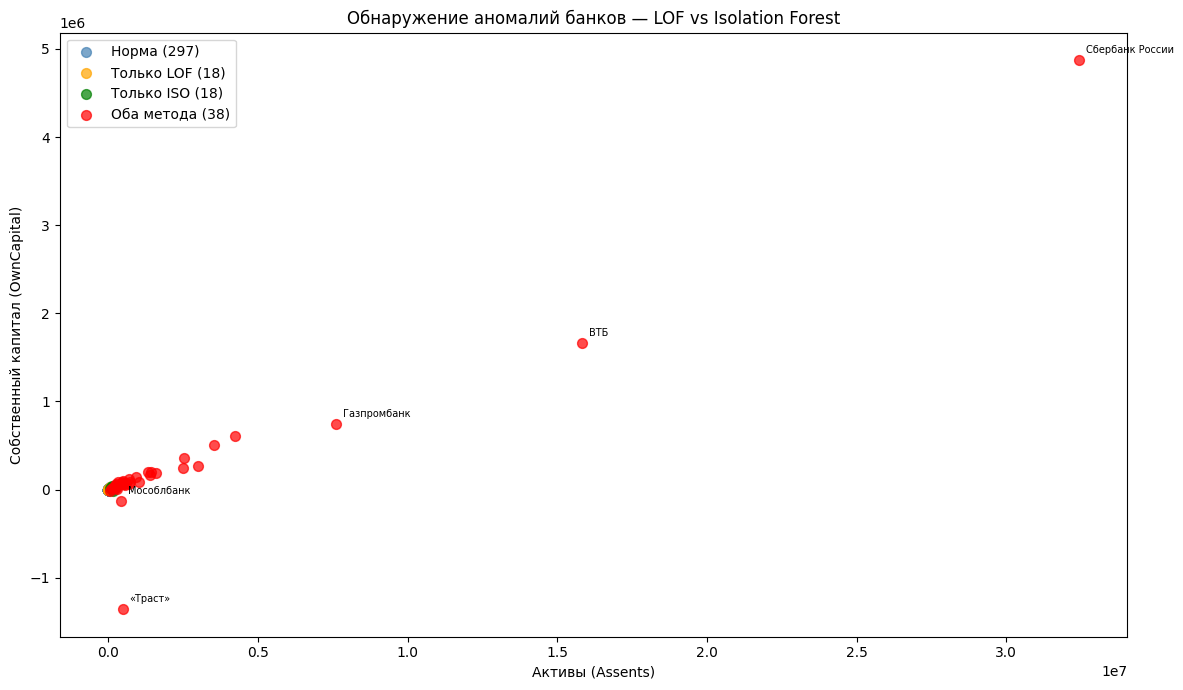

In [13]:
# Категории для визуализации
def get_category(row):
    if row['LOF_label'] == -1 and row['ISO_label'] == -1:
        return 'Оба метода'
    elif row['LOF_label'] == -1:
        return 'Только LOF'
    elif row['ISO_label'] == -1:
        return 'Только ISO'
    else:
        return 'Норма'

df_banks['Category'] = df_banks.apply(get_category, axis=1)

# Цвета для каждой категории
colors = {
    'Норма': 'steelblue',
    'Только LOF': 'orange',
    'Только ISO': 'green',
    'Оба метода': 'red'
}

plt.figure(figsize=(12, 7))

for category, color in colors.items():
    mask = df_banks['Category'] == category
    plt.scatter(
        df_banks[mask]['Assents'],
        df_banks[mask]['OwnCapital'],
        c=color,
        label=f'{category} ({mask.sum()})',
        alpha=0.7,
        s=50
    )

# Подписываем самые интересные банки
top_banks = ['Сбербанк России', 'ВТБ', 'Газпромбанк', '«Траст»', 'Мособлбанк']
for _, row in df_banks[df_banks['Bank'].isin(top_banks)].iterrows():
    plt.annotate(
        row['Bank'],
        (row['Assents'], row['OwnCapital']),
        fontsize=7,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.xlabel('Активы (Assents)')
plt.ylabel('Собственный капитал (OwnCapital)')
plt.title('Обнаружение аномалий банков — LOF vs Isolation Forest')
plt.legend()
plt.tight_layout()
plt.show()

Итоговая визуализация наглядно показывает картину: красные точки (оба метода согласны) — это либо крупнейшие банки страны сильно выбивающиеся по размеру активов, либо проблемные банки с отрицательным капиталом (Траст уходит глубоко вниз до -1.3 трлн, Мособлбанк тоже в минусе). Остальные 297 банков сгруппированы в плотное облако в левом нижнем углу — они похожи друг на друга по масштабу.

Общий вывод по практической работе №12
В ходе работы были применены два метода обнаружения аномалий — LOF и Isolation Forest — на двух принципиально разных датасетах.
По датасету клиентов (diy.txt) оба алгоритма нашли примерно одинаковое число аномалий (141 и 149 соответственно), однако совпали лишь на 4 клиентах. Это говорит о том что алгоритмы смотрят на данные по-разному: LOF оценивает локальную плотность окружения каждого клиента, тогда как Isolation Forest оценивает насколько легко изолировать объект от остальных. На практике это означает что для надёжного результата стоит использовать оба метода и доверять прежде всего тем аномалиям на которых они сходятся.
По датасету банков (banks.txt) картина получилась более содержательной. Алгоритмы уверенно выделили две группы аномалий: крупнейшие системообразующие банки страны (Сбербанк, ВТБ, Газпромбанк, Альфа-банк) — они аномальны не потому что проблемные, а потому что колоссально превосходят остальных по масштабу. И вторая группа — проблемные банки с отрицательным собственным капиталом (Траст, Мособлбанк, Балтинвестбанк) — это уже сигнал финансового неблагополучия.
Главный практический вывод: аномалия — это не всегда что-то плохое. Это просто объект который сильно отличается от остальных. Интерпретация того почему объект является аномалией требует экспертного взгляда на данные, а не только математики.